# Assignment 4
## Submitted by Chaitanya Jindal

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [30]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [31]:
df.describe(include='all')

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [33]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

#### Exploratory Data Analysis (EDA)

In [34]:
df_eda = df.drop('CustomerID', axis=1)

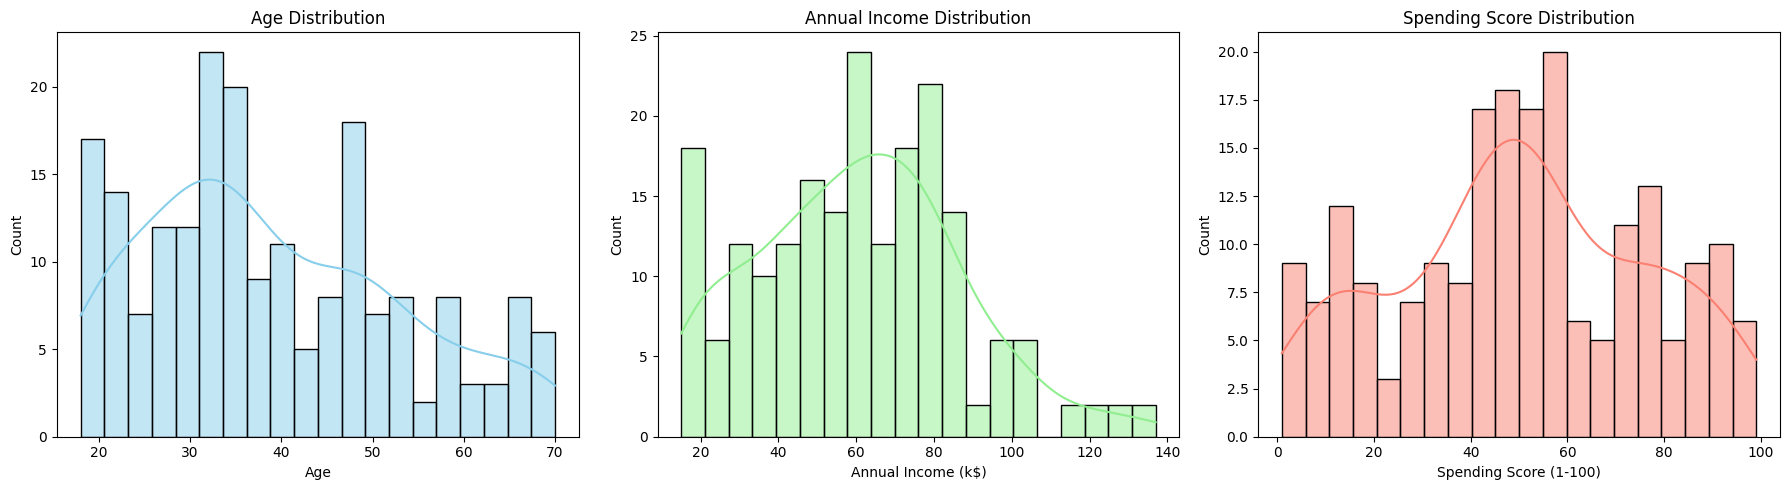

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()


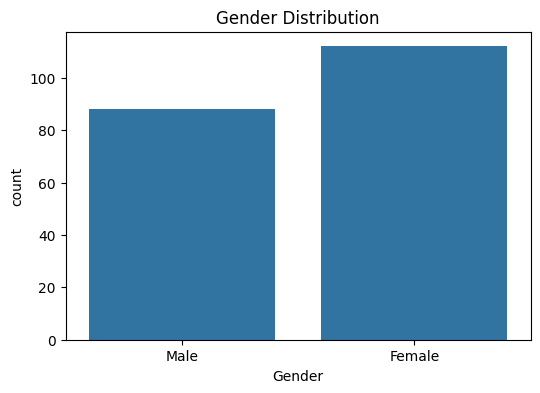

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()

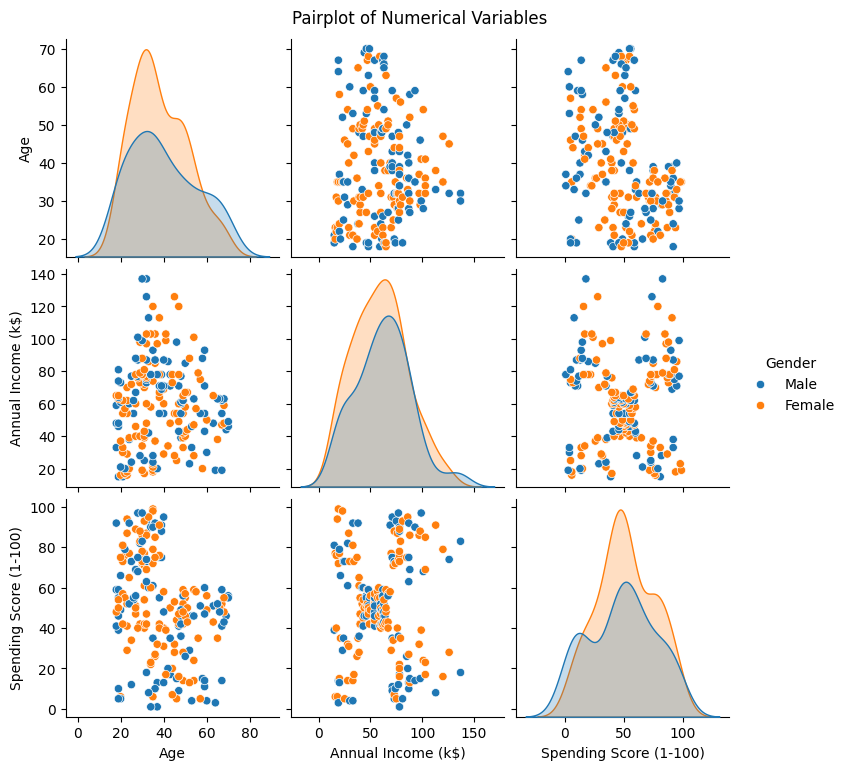

In [37]:
sns.pairplot(df_eda, hue='Gender')
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.show()

#### Data Preprocessing

In [38]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

In [40]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10)
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)
    
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)

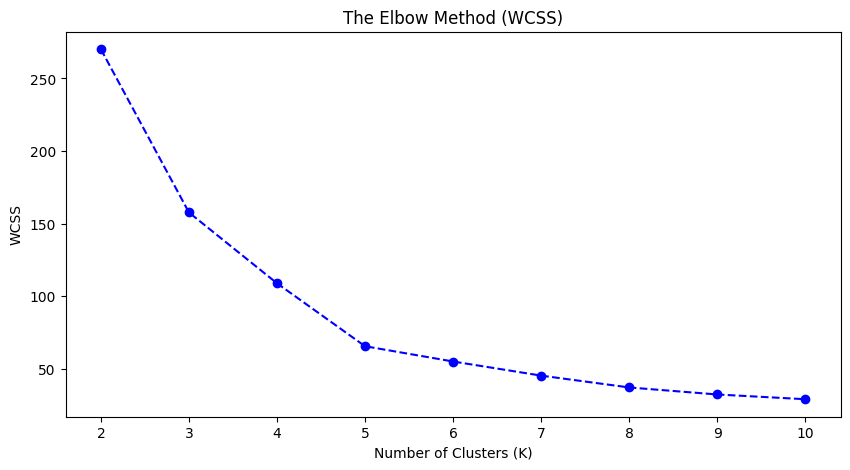

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method (WCSS)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(2, 11))
plt.show()

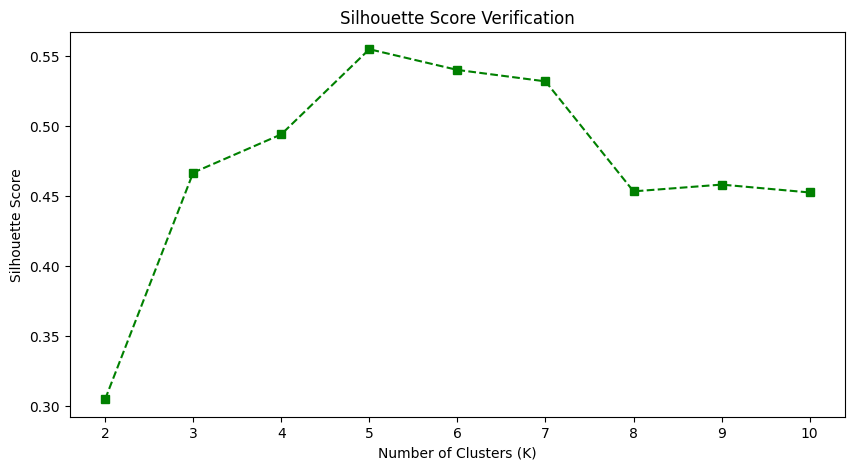

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_scores, marker='s', linestyle='--', color='g')
plt.title('Silhouette Score Verification')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.show()

#### Final Clustering and Visualisations

In [43]:
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

In [44]:
df['Cluster'] = cluster_labels

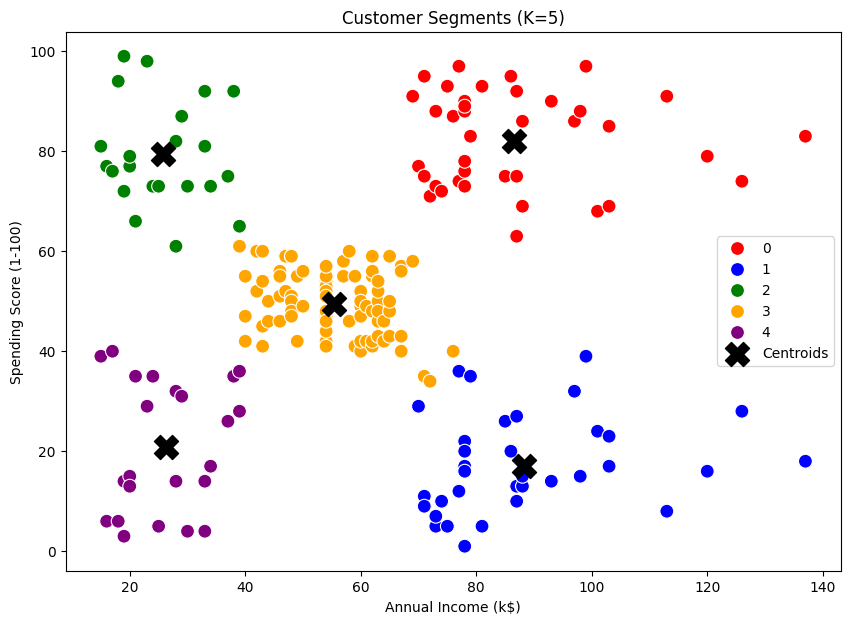

In [45]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    palette=['red', 'blue', 'green', 'orange', 'purple'], 
    data=df, 
    s=100, 
    legend='full'
)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroids')

plt.title('Customer Segments (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [46]:
cluster_analysis = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
display(cluster_analysis)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,32.7,86.5,82.1
1,41.1,88.2,17.1
2,25.3,25.7,79.4
3,42.7,55.3,49.5
4,45.2,26.3,20.9


- Cluster X (High Income, High Spending Score) - "Target / Premium Customers":
Strategy: These are your most loyal and profitable customers. Campaign to them with premium products, exclusive VIP memberships, and early access to new collections.
- Cluster Y (High Income, Low Spending Score) - "Careful / Saver Customers":
Strategy: They have money but don't spend it easily. They value high-quality, durable, and practical goods. Send them targeted campaigns highlighting product value, ROI, and quality guarantees.
- Cluster Z (Average Income, Average Spending Score) - "Standard / Typical Customers":
Strategy: This is your largest volume of customers. Target them with standard promotions, seasonal sales, and loyalty points programs to slowly push them toward a higher spending score.
- Cluster A (Low Income, High Spending Score) - "Careless / Impulsive Customers":
Strategy: These customers love to shop despite lower incomes. Target them with flash sales, discount coupons, and trendy, affordable items.
- Cluster B (Low Income, Low Spending Score) - "Sensible / Lost Customers":
Strategy: They don't earn much and don't spend much. Don't waste high marketing budgets here. Use basic email newsletters with clearance or deep-discount items.